# ![Machine Learning Lab](banner.jpg)

# Laboratorio 11 - Actividad

## Instrucciones generales

1. Esta actividad es de carácter individual. No se permite entregar la actividad después de la fecha establecida.
2. Al responder las preguntas de las actividades, por favor marquen las respuestas con la sección a la que corresponden, por ejemplo: `## 1.1 Descarga de datos`. Es preferible que esto lo hagan con secciones de MarkDown.
3. Por favor asegurarse de que el notebook entregado tenga todas las celdas ejecutadas correctamente.
4. Por favor, nombren el archivo de acuerdo con el siguiente formato `{email}_lab11.ipynb`.
5. Si tienen alguna duda, pueden escribirme a mi correo `j.rayom@uniandes.edu.co` o contactarme directamente por Teams.

---

## Objetivos

1. Aplicar técnicas de procesamiento de lenguaje natural con modelos BERT para resolver una tarea de clasificación de texto multiclase.
2. Comparar el desempeño entre un modelo entrenado desde cero y uno con fine-tuning de un modelo preentrenado.
3. Evaluar modelos con métricas de clasificación.

---

En esta ocasión trabajaremos con el dataset **BBC Full Text Document Classification**, que contiene artículos de noticias de la BBC clasificados en 5 categorías: **business**, **entertainment**, **politics**, **sport** y **tech**.

Dataset: [BBC Full Text Document Classification](https://www.kaggle.com/datasets/alfathterry/bbc-full-text-document-classification)

---

## Instrucciones

### 1. Carga y preparación de datos (10%)

1. Descargue el dataset. La columna `data` contiene los artículos y `labels` es la variable objetivo.
2. Limpie el dataset aplicando preprocesamiento básico de texto (minúsculas, eliminación de caracteres especiales).
3. Separe el dataset en entrenamiento y prueba usando 10% para testing.

---

### 2. Tokenización (10%)

1. Utilice el tokenizador de `bert-base-uncased` para tokenizar los datasets de entrenamiento y prueba.

---

### 3. Definición de arquitectura del modelo (10%)

1. Usando capas densas, agregue una cabeza de clasificación a un modelo BERT.
2. Muestre el resumen del modelo e indique el número total de parámetros.

---

### 4. Entrenamiento desde cero (30%)

1. Parta únicamente de la arquitectura (no use pesos pre-entrenados).
2. Entrene el modelo para predecir las cinco categorías del dataset.
3. Grafique las curvas de pérdida y precisión (entrenamiento vs validación).
4. Valide el modelo usando el dataset de test. Genere un reporte completo de clasificación.

---

### 5. Fine-Tuning con modelo preentrenado (30%)

1. Parta de un modelo BERT pre-entrenado.
2. Entrene el modelo para predecir las cinco categorías del dataset.
3. Grafique las curvas de pérdida y precisión (entrenamiento vs validación).
4. Valide el modelo usando el dataset de test. Genere un reporte completo de clasificación.

---

### 6. Comparación de resultados (10%)

1. Compare el accuracy de ambos modelos en el conjunto de prueba y explique los resultados obtenidos.

---


# **1. Carga y preparación de los datos**

In [1]:
from sklearn.model_selection import train_test_split
import pandas as pd
import re

In [2]:
bbc_data = pd.read_csv("../datasets/bbc_data.csv")

In [3]:
bbc_data.head()

,data,labels
0,Musicians to tackle US red tape Musicians gro...,entertainment
1,"U2s desire to be number one U2, who have won ...",entertainment
2,Rocker Doherty in on-stage fight Rock singer ...,entertainment
3,Snicket tops US box office chart The film ada...,entertainment
4,"Oceans Twelve raids box office Oceans Twelve,...",entertainment


In [4]:
print("ROWS = ", bbc_data.shape[0])
print("COLUMNS = ", bbc_data.shape[1])

ROWS =  2225
COLUMNS =  2


In [5]:
total_count = bbc_data["labels"].value_counts()

print(total_count)
print(f"\nNUMBER OF UNIQUE CLASSES = {len(total_count)}")

labels
sport            511
business         510
politics         417
tech             401
entertainment    386
Name: count, dtype: int64

NUMBER OF UNIQUE CLASSES = 5


In [6]:
def clean_text(text):

    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [7]:
bbc_data["clean_data"] = bbc_data["data"].apply(clean_text)
bbc_data.head()

,data,labels,clean_data
0,Musicians to tackle US red tape Musicians gro...,entertainment,musicians to tackle us red tape musicians grou...
1,"U2s desire to be number one U2, who have won ...",entertainment,u2s desire to be number one u2 who have won th...
2,Rocker Doherty in on-stage fight Rock singer ...,entertainment,rocker doherty in onstage fight rock singer pe...
3,Snicket tops US box office chart The film ada...,entertainment,snicket tops us box office chart the film adap...
4,"Oceans Twelve raids box office Oceans Twelve,...",entertainment,oceans twelve raids box office oceans twelve t...


In [8]:
X_temp, X_test, y_temp, y_test = train_test_split(
    bbc_data["clean_data"], bbc_data["labels"],
    test_size = 0.10,
    random_state = 42,
    stratify = bbc_data["labels"]
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size = (10 / 90),
    random_state = 42,
    stratify = y_temp
)

In [9]:
print(f"TRAIN = {len(X_train)} samples")
print(f"VALIDATION = {len(X_val)} samples")
print(f"TEST = {len(X_test)} samples")

TRAIN = 1779 samples
VALIDATION = 223 samples
TEST = 223 samples


# **2. Tokenización y preparación de los datos**

In [10]:
from sklearn.preprocessing import LabelEncoder
from transformers import BertTokenizer

/home/nico/Desktop/Assignment-11/env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [11]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
print(f"VOCABULARY SIZE = {tokenizer.vocab_size}")

VOCABULARY SIZE = 30522


In [12]:
le = LabelEncoder()
le.fit(bbc_data["labels"])

LabelEncoder()

In [13]:
y_train_enc = le.transform(y_train)
y_val_enc = le.transform(y_val)
y_test_enc = le.transform(y_test)

In [14]:
print("CLASSES = ", list(le.classes_))

CLASSES =  ['business', 'entertainment', 'politics', 'sport', 'tech']


In [15]:
MAX_LEN = 128

In [16]:
def tokenize(texts):
    return tokenizer(
        list(texts),
        padding = True,
        truncation = True,
        max_length = MAX_LEN,
        return_tensors = "pt"
    )

In [17]:
train_encodings = tokenize(X_train)
val_encodings = tokenize(X_val)
test_encodings = tokenize(X_test)

In [18]:
print("TRAIN = ", train_encodings["input_ids"].shape)
print("VALIDATION = ", val_encodings["input_ids"].shape)
print("TEST = ", test_encodings["input_ids"].shape)

TRAIN =  torch.Size([1779, 128])
VALIDATION =  torch.Size([223, 128])
TEST =  torch.Size([223, 128])


# **3. Definición de la arquitectura del modelo**

In [19]:
from transformers import BertModel
import torch.nn as nn
import torch

In [20]:
class BertClassifier(nn.Module):

    def __init__(self, bert_model, num_classes = 5, dropout = 0.3):
        
        super().__init__()

        self.bert = bert_model
        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(self.bert.config.hidden_size, 256)
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, input_ids, attention_mask):

        outputs = self.bert(input_ids = input_ids, attention_mask = attention_mask)
        pooled = outputs.pooler_output

        x = self.dropout(pooled)
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x

In [21]:
bert = BertModel.from_pretrained("bert-base-uncased")
model = BertClassifier(bert)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(model)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 22139.11it/s]
[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BertClassifier(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_af

In [22]:
print(f"TOTAL PARAMETERS = {total_params:,}")
print(f"TRAINABLE PARAMETERS = {trainable_params:,}")

TOTAL PARAMETERS = 109,680,389
TRAINABLE PARAMETERS = 109,680,389


# **4. Entrenamiento del modelo desde cero**

In [23]:
from sklearn.metrics import classification_report
from torch.utils.data import Dataset, DataLoader
from transformers import BertConfig
import matplotlib.pyplot as plt
from torch.optim import Adam

In [24]:
class BBCDataset(Dataset):

    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids": self.encodings["input_ids"][idx],
            "attention_mask": self.encodings["attention_mask"][idx],
            "labels": torch.tensor(self.labels[idx], dtype = torch.long)
        }

In [25]:
BATCH_SIZE = 8

In [26]:
train_dataset = BBCDataset(train_encodings, y_train_enc)
val_dataset = BBCDataset(val_encodings, y_val_enc)
test_dataset = BBCDataset(test_encodings, y_test_enc)

train_loader = DataLoader(train_dataset, batch_size = BATCH_SIZE, shuffle = True)
val_loader = DataLoader(val_dataset, batch_size = BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size = BATCH_SIZE)

In [27]:
print(f"TRAIN BATCHES = {len(train_loader)}")
print(f"VALIDATION BATCHES = {len(val_loader)}")
print(f"TEST BATCHES = {len(test_loader)}")

TRAIN BATCHES = 223
VALIDATION BATCHES = 28
TEST BATCHES = 28


In [28]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE = ", DEVICE)

DEVICE =  cuda


In [29]:
config = BertConfig()
bert_scratch = BertModel(config)
model_scratch = BertClassifier(bert_scratch).to(DEVICE)

In [30]:
EPOCHS = 20
LR = 2e-4

In [31]:
optimizer = Adam(model_scratch.parameters(), lr = LR)
criterion = nn.CrossEntropyLoss()

In [32]:
def train_epoch(model, loader, optimizer, criterion, device):

    model.train()
    total_loss, correct = 0, 0

    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct += (outputs.argmax(dim = 1) == labels).sum().item()

    return total_loss / len(loader), correct / len(loader.dataset)

In [33]:
def eval_epoch(model, loader, criterion, device):

    model.eval()
    total_loss, correct = 0, 0

    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(input_ids, attention_mask)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            correct += (outputs.argmax(dim = 1) == labels).sum().item()

    return total_loss / len(loader), correct / len(loader.dataset)

In [34]:
history_scratch = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

In [35]:
for epoch in range(1, EPOCHS + 1):

    train_loss, train_acc = train_epoch(model_scratch, train_loader, optimizer, criterion, DEVICE)
    val_loss, val_acc = eval_epoch(model_scratch,  val_loader,   criterion, DEVICE)

    history_scratch["train_loss"].append(train_loss)
    history_scratch["val_loss"].append(val_loss)
    history_scratch["train_acc"].append(train_acc)
    history_scratch["val_acc"].append(val_acc)

    print(f"EPOCH {epoch}/{EPOCHS} | TRAIN LOSS = {train_loss:.4f} | TRAIN ACC = {train_acc:.4f} | VAL LOSS = {val_loss:.4f} | VAL ACC = {val_acc:.4f}")

EPOCH 1/20 | TRAIN LOSS = 1.6379 | TRAIN ACC = 0.2142 | VAL LOSS = 1.6095 | VAL ACC = 0.2287
EPOCH 2/20 | TRAIN LOSS = 1.6192 | TRAIN ACC = 0.2142 | VAL LOSS = 1.6208 | VAL ACC = 0.2287
EPOCH 3/20 | TRAIN LOSS = 1.6146 | TRAIN ACC = 0.2108 | VAL LOSS = 1.6049 | VAL ACC = 0.2287
EPOCH 4/20 | TRAIN LOSS = 1.6083 | TRAIN ACC = 0.2333 | VAL LOSS = 1.6067 | VAL ACC = 0.2287
EPOCH 5/20 | TRAIN LOSS = 1.6094 | TRAIN ACC = 0.2254 | VAL LOSS = 1.6055 | VAL ACC = 0.2287
EPOCH 6/20 | TRAIN LOSS = 1.6074 | TRAIN ACC = 0.2322 | VAL LOSS = 1.6028 | VAL ACC = 0.2287
EPOCH 7/20 | TRAIN LOSS = 1.6044 | TRAIN ACC = 0.2203 | VAL LOSS = 1.6034 | VAL ACC = 0.2287
EPOCH 8/20 | TRAIN LOSS = 1.6082 | TRAIN ACC = 0.2170 | VAL LOSS = 1.6042 | VAL ACC = 0.2287
EPOCH 9/20 | TRAIN LOSS = 1.6064 | TRAIN ACC = 0.2417 | VAL LOSS = 1.6040 | VAL ACC = 0.2287
EPOCH 10/20 | TRAIN LOSS = 1.6088 | TRAIN ACC = 0.2142 | VAL LOSS = 1.6077 | VAL ACC = 0.2287
EPOCH 11/20 | TRAIN LOSS = 1.6098 | TRAIN ACC = 0.2170 | VAL LOSS = 1

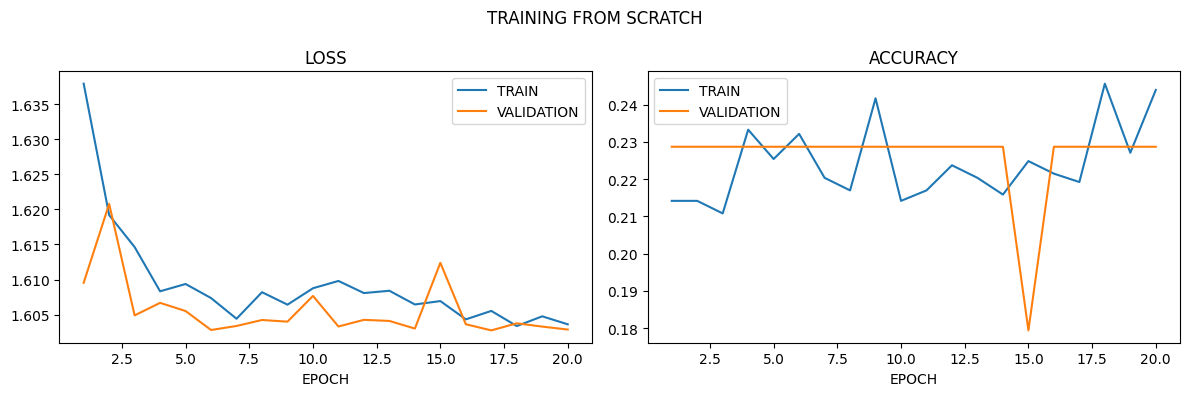

In [36]:
epochs = range(1, EPOCHS + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (12, 4))

ax1.plot(epochs, history_scratch["train_loss"], label = "TRAIN")
ax1.plot(epochs, history_scratch["val_loss"],   label = "VALIDATION")
ax1.set_title("LOSS")
ax1.set_xlabel("EPOCH")
ax1.legend()

ax2.plot(epochs, history_scratch["train_acc"], label = "TRAIN")
ax2.plot(epochs, history_scratch["val_acc"],   label = "VALIDATION")
ax2.set_title("ACCURACY")
ax2.set_xlabel("EPOCH")
ax2.legend()

plt.suptitle("TRAINING FROM SCRATCH")
plt.tight_layout()
plt.show()

In [37]:
model_scratch.eval()
all_preds = []

with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)

        outputs = model_scratch(input_ids, attention_mask)
        preds   = outputs.argmax(dim = 1).cpu().numpy()
        all_preds.extend(preds)

In [38]:
print(classification_report(y_test_enc, all_preds, target_names = le.classes_, zero_division = 0))

               precision    recall  f1-score   support

     business       0.23      1.00      0.37        51
entertainment       0.00      0.00      0.00        39
     politics       0.00      0.00      0.00        42
        sport       0.00      0.00      0.00        51
         tech       0.00      0.00      0.00        40

     accuracy                           0.23       223
    macro avg       0.05      0.20      0.07       223
 weighted avg       0.05      0.23      0.09       223



# **5. Fine-tuning con un modelo pre-entrenado**

In [39]:
import gc

del model_scratch, bert_scratch
gc.collect()
torch.cuda.empty_cache()

print("MEMORY FREED")

MEMORY FREED


In [40]:
bert_pretrained = BertModel.from_pretrained("bert-base-uncased")
model_finetune = BertClassifier(bert_pretrained).to(DEVICE)

print("MODEL LOADED ON DEVICE = ", DEVICE)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 23718.18it/s]
[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


MODEL LOADED ON DEVICE =  cuda


In [41]:
LR_FT = 2e-5
optimizer_ft = Adam(model_finetune.parameters(), lr = LR_FT)

In [42]:
history_finetune = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

In [43]:
for epoch in range(1, EPOCHS + 1):

    train_loss, train_acc = train_epoch(model_finetune, train_loader, optimizer_ft, criterion, DEVICE)
    val_loss, val_acc = eval_epoch(model_finetune,  val_loader,   criterion, DEVICE)

    history_finetune["train_loss"].append(train_loss)
    history_finetune["val_loss"].append(val_loss)
    history_finetune["train_acc"].append(train_acc)
    history_finetune["val_acc"].append(val_acc)

    print(f"EPOCH {epoch}/{EPOCHS} | TRAIN LOSS = {train_loss:.4f} | TRAIN ACC = {train_acc:.4f} | VAL LOSS = {val_loss:.4f} | VAL ACC = {val_acc:.4f}")

EPOCH 1/20 | TRAIN LOSS = 0.7881 | TRAIN ACC = 0.8083 | VAL LOSS = 0.2079 | VAL ACC = 0.9641
EPOCH 2/20 | TRAIN LOSS = 0.1591 | TRAIN ACC = 0.9775 | VAL LOSS = 0.0814 | VAL ACC = 0.9821
EPOCH 3/20 | TRAIN LOSS = 0.0683 | TRAIN ACC = 0.9910 | VAL LOSS = 0.0704 | VAL ACC = 0.9821
EPOCH 4/20 | TRAIN LOSS = 0.0614 | TRAIN ACC = 0.9888 | VAL LOSS = 0.0560 | VAL ACC = 0.9910
EPOCH 5/20 | TRAIN LOSS = 0.0261 | TRAIN ACC = 0.9955 | VAL LOSS = 0.0384 | VAL ACC = 0.9910
EPOCH 6/20 | TRAIN LOSS = 0.0084 | TRAIN ACC = 1.0000 | VAL LOSS = 0.0369 | VAL ACC = 0.9821
EPOCH 7/20 | TRAIN LOSS = 0.0055 | TRAIN ACC = 1.0000 | VAL LOSS = 0.0413 | VAL ACC = 0.9865
EPOCH 8/20 | TRAIN LOSS = 0.0041 | TRAIN ACC = 1.0000 | VAL LOSS = 0.0404 | VAL ACC = 0.9865
EPOCH 9/20 | TRAIN LOSS = 0.0031 | TRAIN ACC = 1.0000 | VAL LOSS = 0.0405 | VAL ACC = 0.9865
EPOCH 10/20 | TRAIN LOSS = 0.0025 | TRAIN ACC = 1.0000 | VAL LOSS = 0.0430 | VAL ACC = 0.9865
EPOCH 11/20 | TRAIN LOSS = 0.0020 | TRAIN ACC = 1.0000 | VAL LOSS = 0

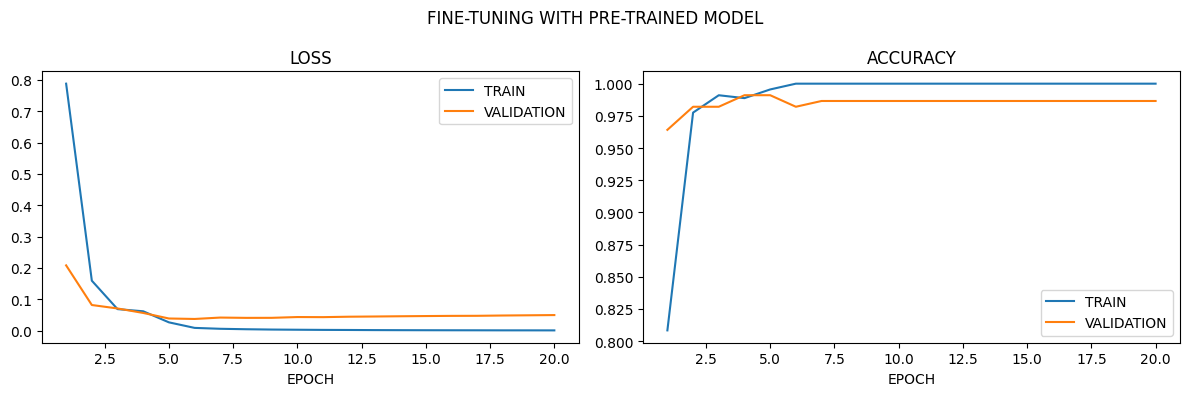

In [44]:
epochs = range(1, EPOCHS + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize = (12, 4))

ax1.plot(epochs, history_finetune["train_loss"], label = "TRAIN")
ax1.plot(epochs, history_finetune["val_loss"],   label = "VALIDATION")
ax1.set_title("LOSS")
ax1.set_xlabel("EPOCH")
ax1.legend()

ax2.plot(epochs, history_finetune["train_acc"], label = "TRAIN")
ax2.plot(epochs, history_finetune["val_acc"],   label = "VALIDATION")
ax2.set_title("ACCURACY")
ax2.set_xlabel("EPOCH")
ax2.legend()

plt.suptitle("FINE-TUNING WITH PRE-TRAINED MODEL")
plt.tight_layout()
plt.show()

In [45]:
model_finetune.eval()
all_preds_ft = []

with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)

        outputs = model_finetune(input_ids, attention_mask)
        preds   = outputs.argmax(dim = 1).cpu().numpy()
        all_preds_ft.extend(preds)

print(classification_report(y_test_enc, all_preds_ft, target_names = le.classes_, zero_division = 0))

               precision    recall  f1-score   support

     business       0.98      1.00      0.99        51
entertainment       1.00      1.00      1.00        39
     politics       1.00      1.00      1.00        42
        sport       1.00      1.00      1.00        51
         tech       1.00      0.97      0.99        40

     accuracy                           1.00       223
    macro avg       1.00      0.99      1.00       223
 weighted avg       1.00      1.00      1.00       223

